# 04 — Follow the Duck through Deep Time

**If you dropped a rubber duck in the ocean near Antarctica, where would it go?**

**Your mission:** compare the duck's journey 60 million years ago with its
journey today, and see how a closing — or opening — sea gateway changes the
route.

This notebook is a deep-time cousin of an activity your class may already
know — tracking a floating object as ocean currents carry it along. Here,
we ask a bigger question: would the duck's journey have been *different*
tens of millions of years ago, before Australia and Antarctica drifted apart?

**A note on honesty**: the duck's path below is *not* a real physics-based
ocean model — real ocean circulation depends on wind, temperature,
saltiness and the shape of every coastline and ocean floor, which is a much
bigger calculation than this notebook does. What it *does* do honestly is
never cross dry land: a grown-up script (`export_data.py`) worked out the
shortest sea-only route between two points using the real, reconstructed
land shape and elevation at each age, the same real data the map picture
itself is made from — so if the path has to bend, it's because real land
was actually in the way.

*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*


## Before you start

Run the cell below first.

In [1]:
# Housekeeping — checks the data files this notebook needs are present.
# If this is the first time anyone has opened Deep Time Explorers, a grown-up
# needs to run export_data.py once (see the suite README) before this will work.
from pathlib import Path
import os as _os

if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

_required = [
    "data/basemap_southern_ocean_0Ma.png",
    "data/basemap_southern_ocean_60Ma.png",
    "data/duck_path.csv",
]
_missing = [f for f in _required if not Path(f).exists()]
if _missing:
    raise FileNotFoundError(
        "Missing data file(s): " + ", ".join(_missing) +
        "\n\nAsk a grown-up to run export_data.py once from the "
        "deep-time-explorers folder — see README.md. "
    )
print("All data files found — ready to go!")


All data files found — ready to go!


In [2]:
# The only packages this notebook needs. In a normal Jupyter/conda install
# these are already there — nothing to do. In the browser-based JupyterLite
# version, `ipywidgets` isn't preinstalled, so the two lines below ask
# Pyodide's package installer to fetch it once, the first time you run this
# cell; they do nothing outside the browser.
import sys
if "pyodide" in sys.modules:
    import piplite
    await piplite.install("ipywidgets")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown


In [3]:
def show_regional_basemap(ax, png_name, extent):
    """Draw a real paleo-elevation background cropped to one region. Because
    this is a simple lat/lon map (not the curved Robinson one), `extent` is
    just (lon_min, lon_max, lat_min, lat_max) and you can plot ordinary
    latitude/longitude points straight on top."""
    img = plt.imread(f"data/{png_name}")
    ax.imshow(img, extent=extent, origin="upper")
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])


## Long ago: Australia and Antarctica were close together

60 million years ago, Australia was still joined to Antarctica along most of
what's now the **Tasmanian Gateway**. A closed gateway leaves no sea-level
route for water (or a duck!) to slip straight through, so anything trying to
sail east has to go the long way round instead.

In [4]:
SOUTHERN_OCEAN_EXTENT = (-148.23529411764602, 126.27450980392128, -99.88235294117608, -17.52941176470589)

# The grown-up script already worked out a real, land-avoiding sea route
# for the duck at each age -- this notebook just loads and plots it.
duck_path = pd.read_csv("data/duck_path.csv")

def plot_duck_journey(age_ma, png_name, title):
    fig, ax = plt.subplots(figsize=(8, 3.2))
    show_regional_basemap(ax, png_name, SOUTHERN_OCEAN_EXTENT)
    path = duck_path[duck_path.age_ma == age_ma]
    ax.plot(path["display_x"], path["lat"], color="orange", linewidth=2, zorder=5)
    ax.scatter([path["display_x"].iloc[0]], [path["lat"].iloc[0]], color="yellow",
               edgecolor="black", s=120, zorder=6, label="Duck dropped here")
    ax.scatter([path["display_x"].iloc[-1]], [path["lat"].iloc[-1]], color="red",
               edgecolor="black", s=120, marker="*", zorder=6, label="Duck ends up here")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)


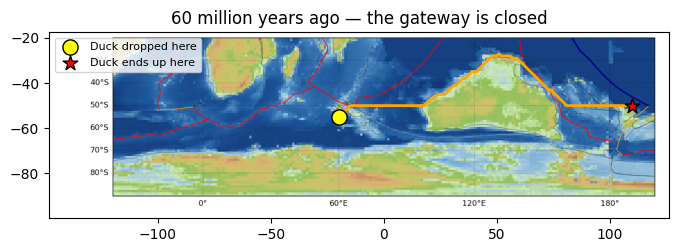

In [5]:
plot_duck_journey(60, "basemap_southern_ocean_60Ma.png",
                   title="60 million years ago — the gateway is closed")


## Today: the gateway is wide open

Now let's drop the same duck in today's wide-open Southern Ocean.

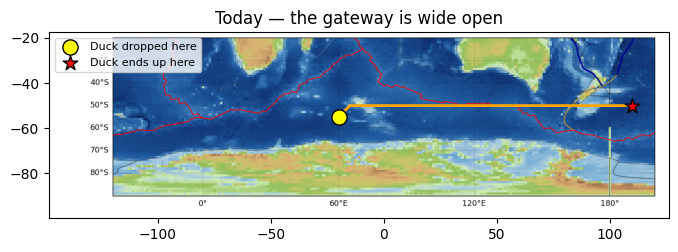

In [6]:
plot_duck_journey(0, "basemap_southern_ocean_0Ma.png",
                   title="Today — the gateway is wide open")


## Compare the two maps

Look at the orange path in both pictures. At 60 Ma, how far south does the
duck have to travel before it can get past Australia? Does today's duck
take a shorter, more direct route — and if so, why?

## What's the big idea?

Real scientists think the opening of gateways like this one — letting water
flow all the way around Antarctica — helped the Southern Ocean grow much
colder over millions of years, which may have helped kick-start Antarctica's
ice sheets. A duck's journey is a fun way to picture something that actually
mattered for the whole planet's climate.

## Try this next!

- Compare `duck_path[duck_path.age_ma == 60]` and `duck_path[duck_path.age_ma == 0]` — how far out of its way (and in which direction) did the duck have to travel at 60 Ma before it could get past Australia?
- Ask a grown-up to add another age (try 80 or 100 Ma) to `DUCK_AGES_MA` near the bottom of `export_data.py` and re-run it — is the gateway even more blocked further back in time, or did it already open a bit?
- Ask a grown-up about the real Antarctic Circumpolar Current and how strong it actually is.

---
*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*
